In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PATHS
# ============================================================

RESULTS_ROOT = Path(
    "/home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results"
)

# ============================================================
# VALIDATION PARAMETERS
# ============================================================

KG_MAP = {
    "KG1": 0.3,
    "KG2": 0.8,
    "KG3": 1.3,
    "KG4": 1.8,
}

FLEX_MAP = {
    "inflex": "Inflexible",
    "flex": "Flexible",
    "highflex": "Highly Flexible",
}

# Experimental geometry
CHORD = 0.1          # m
U_INF = 0.3          # m/s — CHANGE if your simulation uses another value

# Heathcote et al.
H_ROOT = 0.175
A_ROOT_NOMINAL = H_ROOT * CHORD

# Your solver ramps the prescribed motion over first 3 periods
RAMP_CYCLES = 3.0

# Heathcote et al. used 8 oscillations for cosine fitting
N_FIT_CYCLES = 8

print(f"Nominal root amplitude = {A_ROOT_NOMINAL:.6f} m")

Nominal root amplitude = 0.017500 m


In [2]:
def find_solid_diagnostics(case_dir):
    """
    Find solid_diagnostics.csv inside a simulation case.
    """
    candidates = [
        case_dir / "solid" / "diagnostics" / "solid_diagnostics.csv",
        case_dir / "solid" / "solid_diagnostics.csv",
    ]

    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(
        f"Could not find solid_diagnostics.csv in {case_dir}"
    )


datasets = {}

for kg_key, kg_value in KG_MAP.items():
    for flex_key, flex_label in FLEX_MAP.items():

        case_name = f"results_{kg_key}_{flex_key}"
        case_dir = RESULTS_ROOT / case_name

        csv_path = find_solid_diagnostics(case_dir)

        df = pd.read_csv(csv_path)

        datasets[(kg_key, flex_key)] = {
            "kg": kg_value,
            "flexibility": flex_label,
            "case_name": case_name,
            "path": csv_path,
            "df": df,
        }

        print(
            f"{case_name:25s} "
            f"rows={len(df):7d} "
            f"path={csv_path}"
        )

results_KG1_inflex        rows=   3000 path=/home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results/results_KG1_inflex/solid/diagnostics/solid_diagnostics.csv
results_KG1_flex          rows=   3000 path=/home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results/results_KG1_flex/solid/diagnostics/solid_diagnostics.csv
results_KG1_highflex      rows=   3000 path=/home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results/results_KG1_highflex/solid/diagnostics/solid_diagnostics.csv
results_KG2_inflex        rows=   3000 path=/home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results/results_KG2_inflex/solid/diagnostics/solid_diagnostics.csv
results_KG2_flex          rows=   3000 path=/home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results/results_KG2_flex/solid/diagnostics/solid_diagnostics.csv
results_KG2_highflex      rows=   3000 path=/home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results/results_KG2_highflex/solid/diagnostics/solid_diagnostics.csv
results_KG3_inflex        rows=   3000 path=/home/dysco/FL

In [3]:
example_key = ("KG1", "inflex")

df_example = datasets[example_key]["df"]

print(df_example.columns.tolist())

display(df_example.head())

['Step', 'Time', 'Root_Uz', 'Mid_Uz', 'Tip_Uz', 'Root_Vz', 'Mid_Vz', 'Tip_Vz', 'Root_Az', 'Mid_Az', 'Tip_Az', 'ElasticEnergy', 'KineticEnergy', 'DampingEnergy', 'TotalEnergy', 'DeltaE', 'DeltaE_over_E0', 'FluidWork', 'StructuralWork', 'CumFluidWork', 'CumStructuralWork', 'WorkError', 'NewtonIterations', 'NewtonResidual', 'ForceNorm', 'WallTime']


,Step,Time,Root_Uz,Mid_Uz,Tip_Uz,Root_Vz,Mid_Vz,Tip_Vz,Root_Az,Mid_Az,...,DeltaE_over_E0,FluidWork,StructuralWork,CumFluidWork,CumStructuralWork,WorkError,NewtonIterations,NewtonResidual,ForceNorm,WallTime
0,1,0.005,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,-1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,1,0.000000e+00,0.000000e+00,0.000000
1,2,0.010,9.843349e-09,1.743431e-09,-1.321389e-09,0.000004,6.916088e-07,-5.241873e-07,0.001302,0.000231,...,743.512491,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2,4.481721e-14,1.967823e-13,184.380630
2,3,0.015,3.936859e-08,1.296861e-08,-1.040804e-08,0.000008,3.782314e-06,-3.096319e-06,0.000473,0.000877,...,5084.461711,1.528369e-17,1.528454e-17,1.528369e-17,1.528454e-17,0.000008,2,4.898795e-12,3.907728e-10,7.672218
3,4,0.020,8.856131e-08,4.159038e-08,-3.295632e-08,0.000012,7.670516e-06,-5.930248e-06,0.000956,0.000712,...,13212.396574,4.235232e-16,4.235335e-16,4.388069e-16,4.388181e-16,0.000024,2,2.916187e-11,2.329460e-09,0.974471
4,5,0.025,1.573975e-07,8.506596e-08,-5.737482e-08,0.000016,9.732188e-06,-3.873076e-06,0.000717,0.000213,...,24974.957329,3.274577e-15,3.274637e-15,3.713384e-15,3.713455e-15,0.000018,2,8.978632e-11,7.174925e-09,0.967141


In [4]:
# CHANGE THESE ONLY IF YOUR CSV USES DIFFERENT NAMES

TIME_COL = "Time"
ROOT_COL = "Root_Uz"
TIP_COL = "Tip_Uz"

for key, data in datasets.items():
    df = data["df"]

    for col in [TIME_COL, ROOT_COL, TIP_COL]:
        if col not in df.columns:
            raise KeyError(
                f"{col!r} not found in {data['case_name']}. "
                f"Available columns:\n{df.columns.tolist()}"
            )

print("All required columns found.")

All required columns found.


In [5]:
def cosine_fit_fixed_frequency(t, y, omega):
    """
    Fit:

        y(t) = C + A*cos(omega*t) + B*sin(omega*t)

    Equivalent to:

        y(t) = C + amplitude*cos(omega*t + phase)

    Returns
    -------
    amplitude : float
    phase     : float, radians
    offset    : float
    y_fit     : ndarray
    r2        : float
    """

    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(t) & np.isfinite(y)
    t = t[mask]
    y = y[mask]

    X = np.column_stack([
        np.ones_like(t),
        np.cos(omega * t),
        np.sin(omega * t),
    ])

    coeff, *_ = np.linalg.lstsq(X, y, rcond=None)

    C, A, B = coeff

    amplitude = np.sqrt(A**2 + B**2)

    # Because:
    #
    # amplitude*cos(omega*t + phi)
    # = amplitude*cos(phi)*cos(omega*t)
    #   - amplitude*sin(phi)*sin(omega*t)
    #
    # Therefore:
    # A = amplitude*cos(phi)
    # B = -amplitude*sin(phi)

    phase = np.arctan2(-B, A)

    y_fit = X @ coeff

    ss_res = np.sum((y - y_fit)**2)
    ss_tot = np.sum((y - np.mean(y))**2)

    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

    return {
        "amplitude": amplitude,
        "phase_rad": phase,
        "phase_deg": np.degrees(phase),
        "offset": C,
        "fit": y_fit,
        "r2": r2,
        "t": t,
        "y": y,
    }

In [6]:
def select_fit_window(t, frequency,
                      ramp_cycles=3.0,
                      requested_cycles=8):

    t = np.asarray(t, dtype=float)

    # Nondimensional cycle coordinate
    tau = frequency * t       # tau = t/T

    tau_end = np.nanmax(tau)

    # Ramp ends at t/T = 3
    tau_ramp_end = ramp_cycles

    post_ramp_cycles = tau_end - tau_ramp_end

    if post_ramp_cycles <= 0:
        raise ValueError(
            "Simulation ends before the prescribed ramp is complete."
        )

    # Use last 8 complete cycles if possible
    n_cycles_used = min(
        requested_cycles,
        int(np.floor(post_ramp_cycles))
    )

    if n_cycles_used < 1:
        # Special fallback for KG=0.3:
        # use all available post-ramp data
        tau_start = tau_ramp_end
        n_cycles_used = post_ramp_cycles
    else:
        tau_start = tau_end - n_cycles_used

        # Never include ramp
        tau_start = max(tau_start, tau_ramp_end)

    mask = tau >= tau_start

    return {
        "mask": mask,
        "tau": tau,
        "tau_start": tau_start,
        "tau_end": tau_end,
        "cycles_available_post_ramp": post_ramp_cycles,
        "cycles_used": n_cycles_used,
    }

In [7]:
def wrap_to_180(angle_deg):
    """
    Wrap angle to [-180, 180).
    """
    return (angle_deg + 180.0) % 360.0 - 180.0


validation_results = []

for (kg_key, flex_key), data in datasets.items():

    kg = data["kg"]
    df = data["df"]

    t = df[TIME_COL].to_numpy(dtype=float)
    root = df[ROOT_COL].to_numpy(dtype=float)
    tip = df[TIP_COL].to_numpy(dtype=float)

    # Garrick reduced frequency:
    #
    # kG = pi*f*c/U
    #
    # therefore:
    #
    # f = kG*U/(pi*c)

    frequency = kg * U_INF / (np.pi * CHORD)
    omega = 2.0 * np.pi * frequency

    window = select_fit_window(
        t,
        frequency,
        ramp_cycles=RAMP_CYCLES,
        requested_cycles=N_FIT_CYCLES,
    )

    mask = window["mask"]

    t_fit = t[mask]
    root_fit_data = root[mask]
    tip_fit_data = tip[mask]

    # Independently fit root and tip
    root_fit = cosine_fit_fixed_frequency(
        t_fit,
        root_fit_data,
        omega,
    )

    tip_fit = cosine_fit_fixed_frequency(
        t_fit,
        tip_fit_data,
        omega,
    )

    # --------------------------------------------------------
    # Amplitude ratio used by Heathcote et al.
    # --------------------------------------------------------

    amplitude_ratio = (
        tip_fit["amplitude"]
        / root_fit["amplitude"]
    )

    # --------------------------------------------------------
    # Relative phase
    #
    # tip phase - root phase
    #
    # Negative = tip lags root
    # Paper plots positive "phase lag"
    # --------------------------------------------------------

    relative_phase = wrap_to_180(
        tip_fit["phase_deg"]
        - root_fit["phase_deg"]
    )

    phase_lag = -relative_phase

    # Ensure lag is represented as positive 0–180 degrees
    if phase_lag < 0:
        phase_lag += 360.0

    if phase_lag > 180.0:
        phase_lag = 360.0 - phase_lag

    validation_results.append({
        "KG_key": kg_key,
        "kG": kg,
        "Flexibility": data["flexibility"],

        "Frequency_Hz": frequency,

        "Root_amplitude_fit": root_fit["amplitude"],
        "Tip_amplitude_fit": tip_fit["amplitude"],

        "Amplitude_ratio": amplitude_ratio,

        "Root_phase_deg": root_fit["phase_deg"],
        "Tip_phase_deg": tip_fit["phase_deg"],

        "Relative_phase_deg": relative_phase,
        "Phase_lag_deg": phase_lag,

        "Root_R2": root_fit["r2"],
        "Tip_R2": tip_fit["r2"],

        "Post_ramp_cycles": window[
            "cycles_available_post_ramp"
        ],

        "Fit_cycles": window["cycles_used"],

        "Fit_start_t_over_T": window["tau_start"],
        "Fit_end_t_over_T": window["tau_end"],
    })


results_df = pd.DataFrame(validation_results)

results_df = results_df.sort_values(
    ["kG", "Flexibility"]
).reset_index(drop=True)

display(results_df)

,KG_key,kG,Flexibility,Frequency_Hz,Root_amplitude_fit,Tip_amplitude_fit,Amplitude_ratio,Root_phase_deg,Tip_phase_deg,Relative_phase_deg,Phase_lag_deg,Root_R2,Tip_R2,Post_ramp_cycles,Fit_cycles,Fit_start_t_over_T,Fit_end_t_over_T
0,KG1,0.3,Flexible,0.286479,0.0175,0.017646,1.008350,-0.515662,-0.474853,0.040809,0.040809,1.0,1.000000,1.297183,1,3.297183,4.297183
1,KG1,0.3,Highly Flexible,0.286479,0.0175,0.017996,1.028348,-0.515662,-0.382518,0.133144,0.133144,1.0,1.000000,1.297183,1,3.297183,4.297183
2,KG1,0.3,Inflexible,0.286479,0.0175,0.017524,1.001382,-0.515662,-0.508883,0.006779,0.006779,1.0,1.000000,1.297183,1,3.297183,4.297183
3,KG2,0.8,Flexible,0.763944,0.0175,0.018574,1.061398,-1.375099,-1.270774,0.104325,0.104325,1.0,0.999999,8.459156,8,3.459156,11.459156
4,KG2,0.8,Highly Flexible,0.763944,0.0175,0.021477,1.227252,-1.375099,-1.030773,0.344326,0.344326,1.0,0.999986,8.459156,8,3.459156,11.459156
5,KG2,0.8,Inflexible,0.763944,0.0175,0.017673,1.009882,-1.375099,-1.357551,0.017547,0.017547,1.0,1.000000,8.459156,8,3.459156,11.459156
6,KG3,1.3,Flexible,1.241409,0.0175,0.020537,1.173549,-2.234535,-2.071947,0.162588,0.162588,1.0,0.999999,15.621128,8,10.621128,18.621128
7,KG3,1.3,Highly Flexible,1.241409,0.0175,0.031448,1.797024,-2.234535,-1.731076,0.503459,0.503459,1.0,0.995533,15.621128,8,10.621128,18.621128
8,KG3,1.3,Inflexible,1.241409,0.0175,0.017962,1.026377,-2.234535,-2.207134,0.027401,0.027401,1.0,1.000000,15.621128,8,10.621128,18.621128
9,KG4,1.8,Flexible,1.718873,0.0175,0.023999,1.371387,-3.093972,-2.896930,0.197043,0.197043,1.0,0.999670,22.783101,8,17.783101,25.783101


In [8]:
check_cols = [
    "kG",
    "Flexibility",
    "Root_amplitude_fit",
    "Tip_amplitude_fit",
    "Amplitude_ratio",
    "Phase_lag_deg",
    "Root_R2",
    "Tip_R2",
    "Post_ramp_cycles",
    "Fit_cycles",
]

display(
    results_df[check_cols].round(4)
)

,kG,Flexibility,Root_amplitude_fit,Tip_amplitude_fit,Amplitude_ratio,Phase_lag_deg,Root_R2,Tip_R2,Post_ramp_cycles,Fit_cycles
0,0.3,Flexible,0.0175,0.0176,1.0084,0.0408,1.0,1.0000,1.2972,1
1,0.3,Highly Flexible,0.0175,0.0180,1.0283,0.1331,1.0,1.0000,1.2972,1
2,0.3,Inflexible,0.0175,0.0175,1.0014,0.0068,1.0,1.0000,1.2972,1
3,0.8,Flexible,0.0175,0.0186,1.0614,0.1043,1.0,1.0000,8.4592,8
4,0.8,Highly Flexible,0.0175,0.0215,1.2273,0.3443,1.0,1.0000,8.4592,8
5,0.8,Inflexible,0.0175,0.0177,1.0099,0.0175,1.0,1.0000,8.4592,8
6,1.3,Flexible,0.0175,0.0205,1.1735,0.1626,1.0,1.0000,15.6211,8
7,1.3,Highly Flexible,0.0175,0.0314,1.7970,0.5035,1.0,0.9955,15.6211,8
8,1.3,Inflexible,0.0175,0.0180,1.0264,0.0274,1.0,1.0000,15.6211,8
9,1.8,Flexible,0.0175,0.0240,1.3714,0.1970,1.0,0.9997,22.7831,8


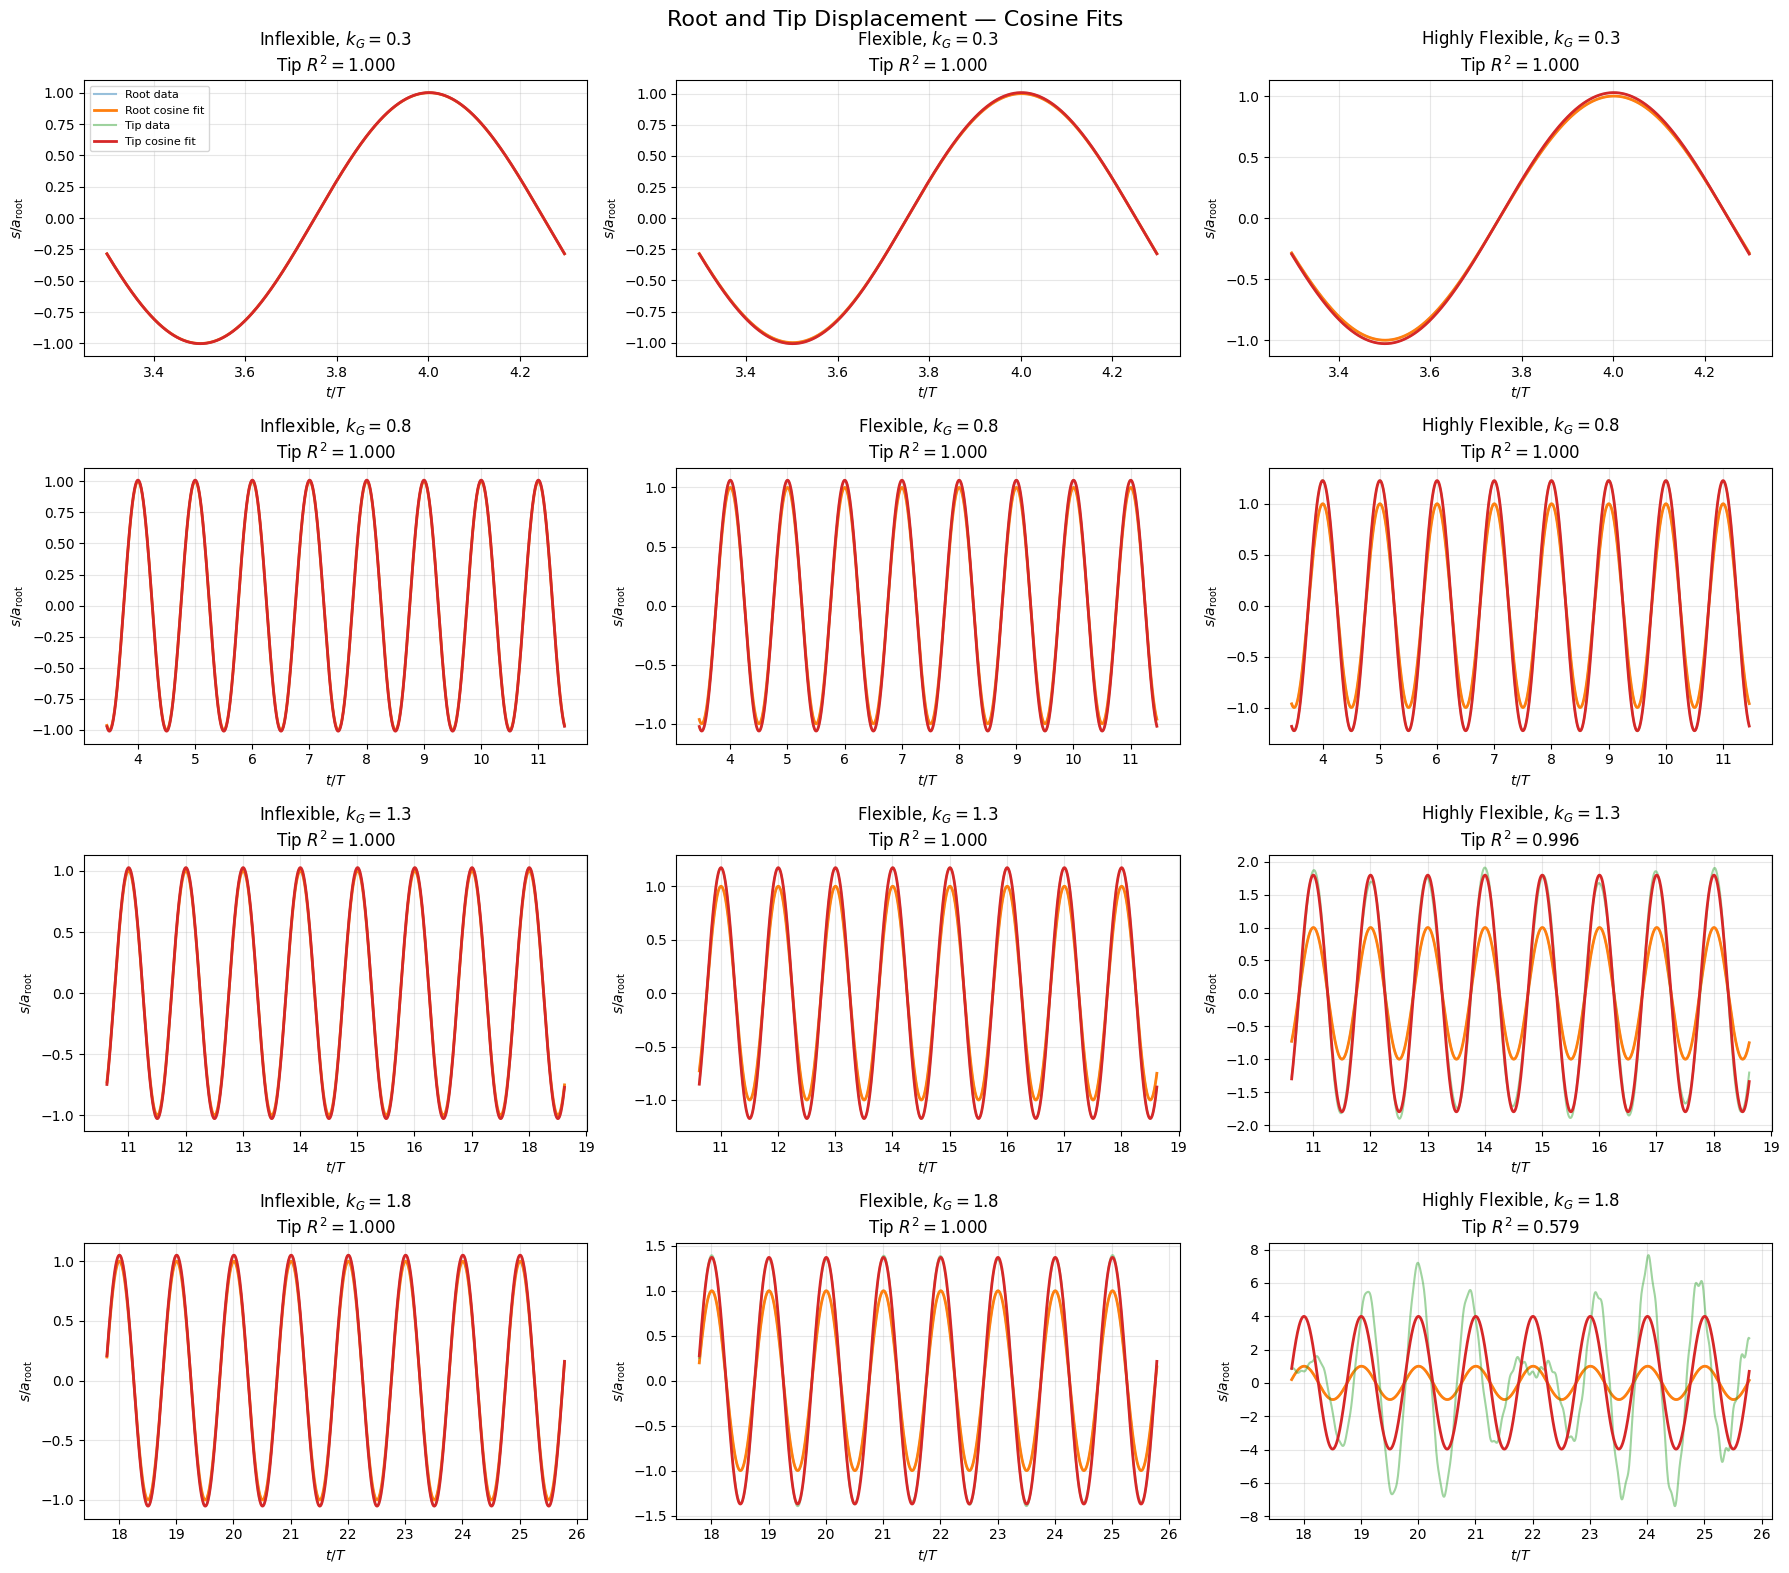

In [9]:
fig, axes = plt.subplots(
    4,
    3,
    figsize=(18, 16),
    sharex=False,
)

for row, (kg_key, kg) in enumerate(KG_MAP.items()):

    for col, (flex_key, flex_label) in enumerate(FLEX_MAP.items()):

        ax = axes[row, col]

        data = datasets[(kg_key, flex_key)]
        df = data["df"]

        t = df[TIME_COL].to_numpy(dtype=float)
        root = df[ROOT_COL].to_numpy(dtype=float)
        tip = df[TIP_COL].to_numpy(dtype=float)

        frequency = kg * U_INF / (np.pi * CHORD)
        omega = 2 * np.pi * frequency

        window = select_fit_window(
            t,
            frequency,
            RAMP_CYCLES,
            N_FIT_CYCLES,
        )

        mask = window["mask"]

        t_sel = t[mask]
        tau_sel = frequency * t_sel

        root_result = cosine_fit_fixed_frequency(
            t_sel,
            root[mask],
            omega,
        )

        tip_result = cosine_fit_fixed_frequency(
            t_sel,
            tip[mask],
            omega,
        )

        # Normalize using FITTED root amplitude
        a_root_fit = root_result["amplitude"]

        ax.plot(
            tau_sel,
            root[mask] / a_root_fit,
            alpha=0.45,
            label="Root data",
        )

        ax.plot(
            tau_sel,
            root_result["fit"] / a_root_fit,
            linewidth=2,
            label="Root cosine fit",
        )

        ax.plot(
            tau_sel,
            tip[mask] / a_root_fit,
            alpha=0.45,
            label="Tip data",
        )

        ax.plot(
            tau_sel,
            tip_result["fit"] / a_root_fit,
            linewidth=2,
            label="Tip cosine fit",
        )

        ax.set_title(
            f"{flex_label}, $k_G={kg}$\n"
            f"Tip $R^2={tip_result['r2']:.3f}$"
        )

        ax.set_xlabel(r"$t/T$")
        ax.set_ylabel(
            r"$s/a_{\mathrm{root}}$"
        )

        ax.grid(alpha=0.3)

        if row == 0 and col == 0:
            ax.legend(fontsize=8)


plt.suptitle(
    "Root and Tip Displacement — Cosine Fits",
    fontsize=16,
)

plt.tight_layout()
plt.show()

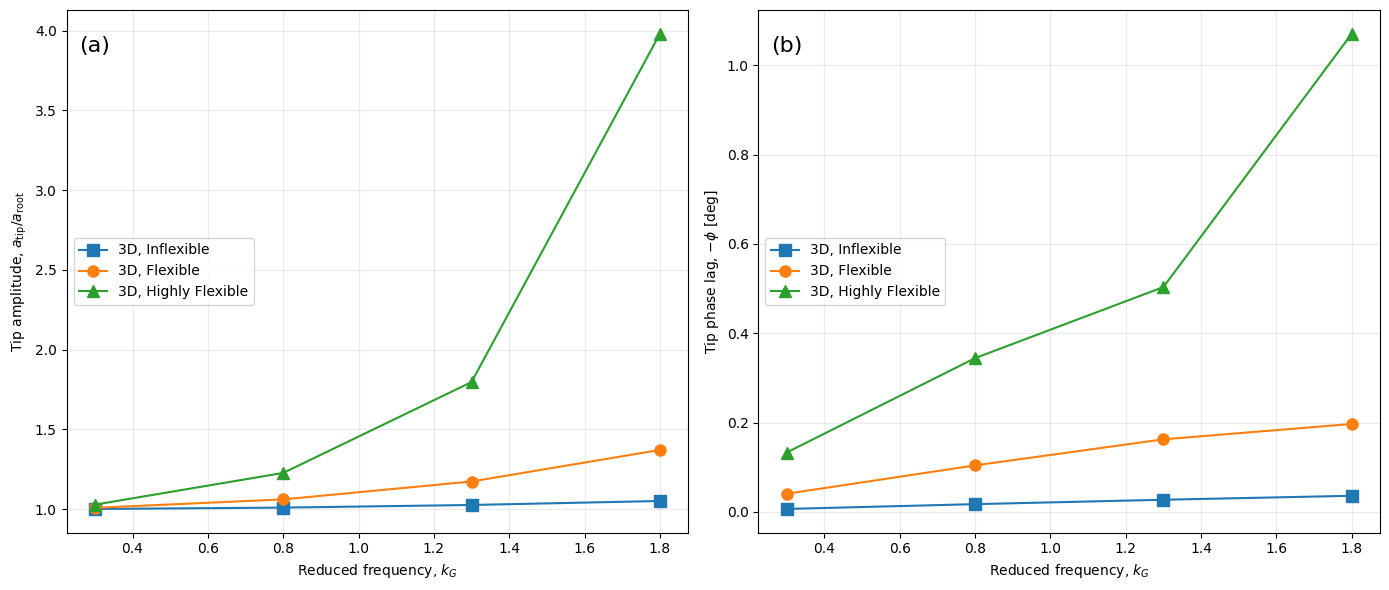

In [10]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6),
)

markers = {
    "Inflexible": "s",
    "Flexible": "o",
    "Highly Flexible": "^",
}

for flex_label in [
    "Inflexible",
    "Flexible",
    "Highly Flexible",
]:

    sub = results_df[
        results_df["Flexibility"] == flex_label
    ].sort_values("kG")

    # --------------------------------------------------------
    # (a) Tip amplitude
    # --------------------------------------------------------

    axes[0].plot(
        sub["kG"],
        sub["Amplitude_ratio"],
        marker=markers[flex_label],
        markersize=8,
        linewidth=1.5,
        label=f"3D, {flex_label}",
    )

    # --------------------------------------------------------
    # (b) Tip phase lag
    # --------------------------------------------------------

    axes[1].plot(
        sub["kG"],
        sub["Phase_lag_deg"],
        marker=markers[flex_label],
        markersize=8,
        linewidth=1.5,
        label=f"3D, {flex_label}",
    )


axes[0].set_xlabel(
    r"Reduced frequency, $k_G$"
)

axes[0].set_ylabel(
    r"Tip amplitude, $a_{\mathrm{tip}}/a_{\mathrm{root}}$"
)

axes[0].legend()
axes[0].grid(alpha=0.25)

axes[0].text(
    0.02,
    0.95,
    "(a)",
    transform=axes[0].transAxes,
    fontsize=16,
    va="top",
)


axes[1].set_xlabel(
    r"Reduced frequency, $k_G$"
)

axes[1].set_ylabel(
    r"Tip phase lag, $-\phi$ [deg]"
)

axes[1].legend()
axes[1].grid(alpha=0.25)

axes[1].text(
    0.02,
    0.95,
    "(b)",
    transform=axes[1].transAxes,
    fontsize=16,
    va="top",
)

plt.tight_layout()
plt.show()